# Llama 3.2 1B Instruct — Usage

Education purpose only. The examples below use **llama_3_2_1B instruct** with minimal code.

In [ ]:
# conda create -n testllm_env python=3.10 -y
# conda activate testllm_env
# pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128
# pip install transformers accelerate
# pip install ipywidgets

In [100]:
import os
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

HF_TOKEN = os.getenv("HF_TOKEN")
MODEL_ID = "meta-llama/Llama-3.2-1B-Instruct"

os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "0"

try:
    print(f"Loading model: {MODEL_ID}...")
    
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, token=HF_TOKEN)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        token=HF_TOKEN,
        dtype=torch.float16,
        device_map="auto",
        low_cpu_mem_usage=True,
    )
    
    # disable default max_length on generation_config to avoid conflict with max_new_tokens
    model.generation_config.max_length = None
    
    print("Model loaded successfully!")

except Exception as e:
    print(f"Error loading model: {e}")

Loading model: meta-llama/Llama-3.2-1B-Instruct...


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Model loaded successfully!


In [105]:
# Cell 2 — Helper (use model.generate directly to avoid pipeline sequential warning)
def chat(messages, max_new_tokens=200, temperature=0.7):
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    # print("=== Keys ===")
    # print(list(inputs.keys()))

    # print("\n=== input_ids ===")
    # print(inputs["input_ids"])
    # print(f"Shape: {inputs['input_ids'].shape}")

    # print("\n=== attention_mask ===")
    # print(inputs["attention_mask"])
    # print(f"Shape: {inputs['attention_mask'].shape}")

    # print("\n=== Token ↔ ID Mapping ===")
    # for token_id in inputs["input_ids"][0]:
    #     token = tokenizer.decode(token_id)
    #     print(f"  {token_id.item():>6} → '{token}'")
    
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )
    # decode only the new tokens (skip the prompt tokens)
    
    
    new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

## Template 1 — Chatbot (Conversational Assistant)
A simple chatbot example.

In [106]:
# Cell 3 — Template 1: Chatbot
messages = [
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user",   "content": "What should I prepare before learning Python?"},
]
print(chat(messages, max_new_tokens=160))

Before diving into learning Python, here's a suggested preparation checklist to get you started:

1. **Familiarize yourself with basic computer concepts**:
	* Understand the basics of computer programming, such as variables, data types, operators, control structures, functions, and object-oriented programming (OOP) concepts.
2. **Choose a text editor or IDE**:
	* Select a text editor or Integrated Development Environment (IDE) that you're comfortable with, such as PyCharm, Visual Studio Code, or Sublime Text.
	* Familiarize yourself with the interface, basic shortcuts, and key features.
3. **Install a Python interpreter**:
	* Download and install the latest version of Python from the official Python website (python.org).
	* Make sure you have the


## Template 2 — Text Summarization & Transformation
Summarize and rewrite text in a simpler way.

In [107]:
# Cell 4 — Template 2: Summarization & Transformation
text = (
    "Artificial intelligence can greatly assist human life, but it also raises "
    "concerns about data security and ethical issues that must be carefully considered."
)

messages = [
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user",   "content": f"Summarize the following text in 3 bullet points, then rewrite it so a child can understand.\n\n{text}"},
]
print(chat(messages, max_new_tokens=200))

Here are 3 bullet points summarizing the text:

• Artificial intelligence (AI) can be very helpful, but it also needs to be used carefully to protect people's personal information and ensure it's used in a way that's fair and respectful.
• There are some concerns about how AI is being used, like making decisions about people's lives without being asked, which can be unfair.
• We need to think carefully about how we use AI so that it doesn't cause any harm or problems, and that it's used to help people, not to hurt them.

And here's a rewritten version of the text that a child can understand:

"Do you know that computers can be very smart and help us in many ways? But we need to be careful about how we use them. Sometimes, we use them to make decisions about people, like who gets to go to school or where they go to live. And sometimes, we might not ask if we want the computer to make those decisions for us


## Template 3 — Zero-shot Learning
Classify text without providing any examples.

In [109]:
# Cell 5 — Template 3: Zero-shot Classification
messages = [
    {"role": "system", "content": "You are a classifier. Reply with one label only."},
    {"role": "user",   "content": "Labels: Education, Health, Technology, Business\n\nSentence: AI can be used in online education.\n\nLabel:"},
]
print(chat(messages, max_new_tokens=20, temperature=0.1))

Education


## Template 4 — Few-shot Learning
Classify text by providing a few examples first.

In [110]:
# Cell 6 — Template 4: Few-shot Classification
messages = [
    {"role": "system", "content": "You are a classifier. Reply with one label only."},
    {"role": "user",   "content": (
        "Example 1: Advise students on managing their reading time → Education\n"
        "Example 2: Suggest ways to increase sales in online markets → Business\n"
        "Example 3: Why is hand washing important → Health\n\n"
        "Classify: Doing exercise everyday is so important →"
    )},
]
print(chat(messages, max_new_tokens=20, temperature=0.1))

Health


---
# Inference Methods Comparison

Model ကို text generate လုပ်ဖို့ နည်းလမ်း **၃ မျိုး** ရှိပါတယ်။

| Method | Level | Control | Ease |
|--------|-------|---------|------|
| `pipeline(...)` | High-level | ✦☆☆ | Easy — input/output ကို auto handle လုပ်ပေးတယ် |
| `model.generate(...)` | Mid-level | ✦✦☆ | Medium — tokenize/decode ကိုယ်တိုင်လုပ်ရတယ် |
| `model(...)` forward pass | Low-level | ✦✦✦ | Hard — logits ကနေ token ကိုယ်တိုင်ရွေးရတယ် |

In [111]:
# Same prompt for all 3 methods
test_messages = [
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user",   "content": "What is AI in one sentence?"},
]
test_prompt = tokenizer.apply_chat_template(test_messages, tokenize=False, add_generation_prompt=True)

## Method 1 — `pipeline` (High-level)
- Code အနည်းဆုံးရေးရတယ်
- Tokenize, generate, decode အကုန် auto လုပ်ပေးတယ်
- Prototype / quick demo အတွက် အကောင်းဆုံး
- **အားနည်းချက်**: batch processing မရှိရင် sequential GPU warning ပေါ်နိုင်တယ်

In [113]:
# Method 1: pipeline — just pass the prompt string, get result back
from transformers import pipeline
import time

generator = pipeline("text-generation", model=model, tokenizer=tokenizer)

start = time.time()
result = generator(
    test_prompt,
    max_new_tokens=50,
    temperature=0.7,
    do_sample=True,
    pad_token_id=tokenizer.eos_token_id,
)
reply = result[0]["generated_text"][len(test_prompt):].strip()
elapsed = time.time() - start

print(f"[pipeline] ({elapsed:.2f}s)")
print(reply)

Both `max_new_tokens` (=50) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[pipeline] (0.59s)
Artificial intelligence (AI) refers to the development of computer systems that can perform tasks that would typically require human intelligence, such as learning, problem-solving, and decision-making, often using algorithms and data.


## Method 2 — `model.generate()` (Mid-level)
- Tokenize / decode ကိုယ်တိုင်လုပ်ရတယ်
- Generation parameters (beam search, sampling, etc.) ကို ပိုထိန်းချုပ်နိုင်တယ်
- **Production code** နဲ့ **custom decoding** အတွက် အသုံးများတယ်
- Sequential warning မရှိ

In [114]:
# Method 2: model.generate() — tokenize yourself, more control
start = time.time()

inputs = tokenizer(test_prompt, return_tensors="pt").to(model.device)

with torch.no_grad():
    output_ids = model.generate(
        **inputs,
        max_new_tokens=50,
        temperature=0.7,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id,
    )

# decode only new tokens
new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
reply = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
elapsed = time.time() - start

print(f"[model.generate] ({elapsed:.2f}s)")
print(reply)

[model.generate] (0.54s)
Artificial intelligence (AI) refers to the development of computer systems that can perform tasks that typically require human intelligence, such as learning, problem-solving, decision-making, and perception, without being explicitly programmed.


## Method 3 — `model()` Forward Pass (Low-level)
- Model ကနေ **logits** (raw probability scores) ကို ယူပြီး token ကိုယ်တိုင်ရွေးရတယ်
- Token တစ်လုံးချင်း loop ပတ်ပြီး generate လုပ်ရတယ်
- **Custom sampling**, **logit manipulation**, **research** အတွက် သုံးတယ်
- LLM အတွင်းပိုင်း ဘယ်လိုအလုပ်လုပ်တယ်ဆိုတာ နားလည်ဖို့ အကောင်းဆုံး

In [117]:
# Method 3: manual forward pass — token-by-token loop, full control
start = time.time()

inputs = tokenizer(test_prompt, return_tensors="pt").to(model.device)
generated_ids = inputs["input_ids"].clone()

max_new_tokens = 50
temperature = 0.7

with torch.no_grad():
    for _ in range(max_new_tokens):
        # forward pass → get logits for next token
        outputs = model(input_ids=generated_ids)
        next_token_logits = outputs.logits[:, -1, :]   # shape: (1, vocab_size)
        # logits.shape = (batch_size, sequence_length, vocab_size)
        #             ↑              ↑              ↑
        #           [:, ]         [-1, ]          [:]

        # ဥပမာ: (1, 5, 128256)
        # ဘာကြောင့် -1 (နောက်ဆုံး position) ပဲ ယူလဲ
        # Causal LM မှာ position တစ်ခုချင်းတိုင်း က "ဒီ token ပြီးရင် ဘာလာမလဲ" ဆိုတာ predict လုပ်တယ်:

        # apply temperature scaling
        scaled_logits = next_token_logits / temperature

        # sample from probability distribution
        probs = torch.softmax(scaled_logits, dim=-1)
        next_token_id = torch.multinomial(probs, num_samples=1)

        # stop if EOS token
        if next_token_id.item() == tokenizer.eos_token_id:
            break

        # append new token and continue
        generated_ids = torch.cat([generated_ids, next_token_id], dim=-1)

# decode only new tokens
new_tokens = generated_ids[0][inputs["input_ids"].shape[1]:]
reply = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
elapsed = time.time() - start

print(f"[manual forward pass] ({elapsed:.2f}s)")
print(reply)

[manual forward pass] (0.86s)
Artificial intelligence (AI) refers to the development of computer systems that can perform tasks that typically require human intelligence, such as learning, problem-solving, decision-making, and perception, without being explicitly programmed for a specific task.


## Method 3b — Forward Pass with KV Cache (Optimized Low-level)
- Method 3 လိုပဲ manual loop ပတ်တာပဲ ဒါပေမယ့် **KV Cache** သုံးထားလို့ ပိုမြန်တယ်
- Token အသစ်တစ်လုံးတိုင်း prompt တစ်ခုလုံးကို ပြန်မတွက်ဘဲ cache ထဲက ယူသုံးတယ်
- `model.generate()` ကလည်း internally ဒီနည်းကိုပဲ သုံးတယ်

In [118]:
# Method 3b: manual forward pass WITH KV cache — much faster than Method 3
start = time.time()

inputs = tokenizer(test_prompt, return_tensors="pt").to(model.device)
generated_ids = inputs["input_ids"].clone()

max_new_tokens = 50
temperature = 0.7
past_key_values = None

with torch.no_grad():
    for i in range(max_new_tokens):
        if i == 0:
            # first pass: process full prompt
            outputs = model(input_ids=generated_ids, use_cache=True)
        else:
            # subsequent passes: only process the last token, reuse cache
            outputs = model(input_ids=next_token_id, past_key_values=past_key_values, use_cache=True)

        past_key_values = outputs.past_key_values   # save KV cache
        next_token_logits = outputs.logits[:, -1, :]

        scaled_logits = next_token_logits / temperature
        probs = torch.softmax(scaled_logits, dim=-1)
        next_token_id = torch.multinomial(probs, num_samples=1)

        if next_token_id.item() == tokenizer.eos_token_id:
            break

        generated_ids = torch.cat([generated_ids, next_token_id], dim=-1)

new_tokens = generated_ids[0][inputs["input_ids"].shape[1]:]
reply = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
elapsed = time.time() - start

print(f"[manual forward + KV cache] ({elapsed:.2f}s)")
print(reply)

[manual forward + KV cache] (0.53s)
Artificial intelligence (AI) refers to the development of computer systems that can perform tasks that typically require human intelligence, such as learning, problem-solving, and decision-making without explicit programming or human intervention.


## အသုံးပြုနည်း Fuction Call များ

```
pipeline(...)          → code နည်း, auto handle, quick prototyping
model.generate(...)    → tokenize ကိုယ်တိုင်, generation params ထိန်းချုပ်နိုင်, production ready
model() forward pass   → logits ယူ, token ကိုယ်တိုင်ရွေး, research / custom sampling
model() + KV cache     → forward pass + cache reuse, Method 3 ထက် အဆများစွာ ပိုမြန်
```

> **Tip**: Education / demo → `pipeline` သုံး။ Production → `model.generate()` သုံး။
> LLM internals လေ့လာချင်ရင် → manual forward pass စမ်းကြည့်ပါ။

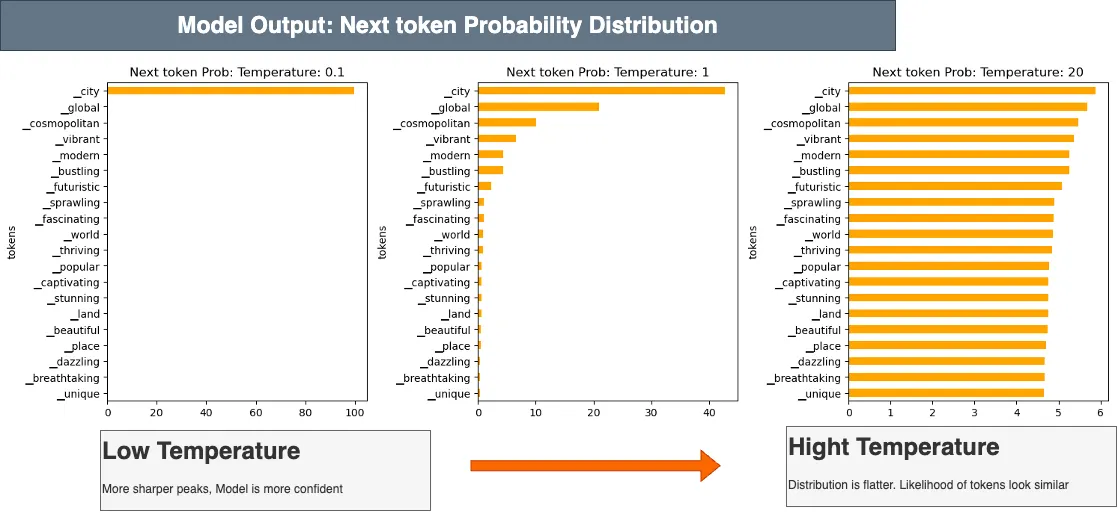

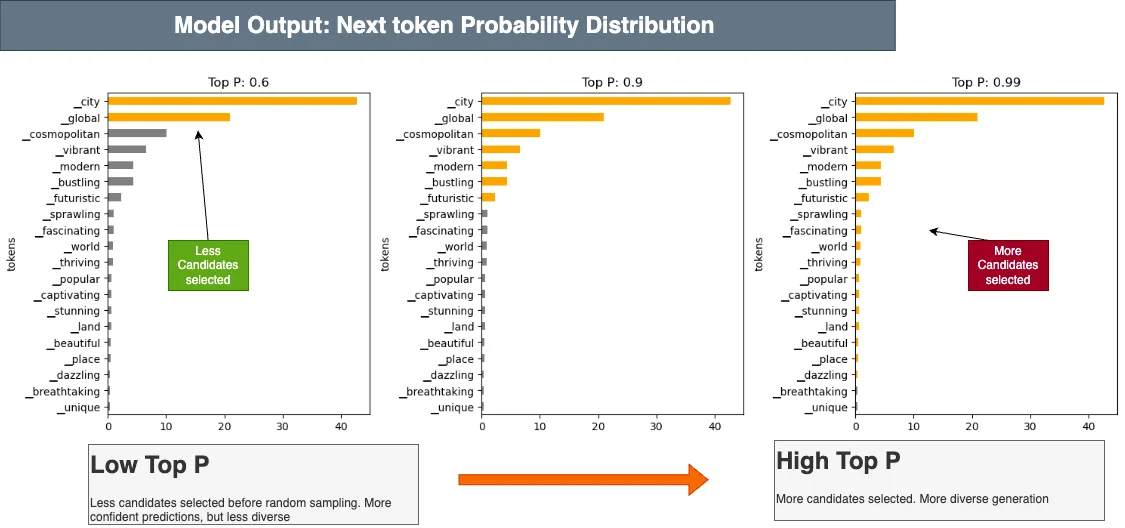

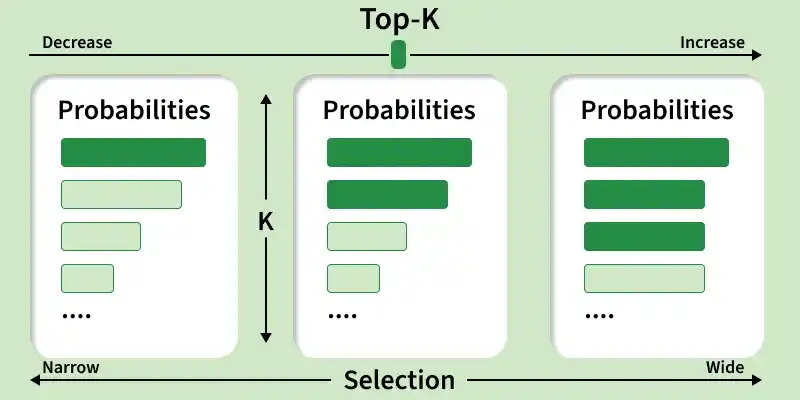

---
# Handling Incomplete Output (max_new_tokens Cutoff)

`max_new_tokens` ကန့်သတ်ချက်ကြောင့် စာကြောင်း မပြည့်ခင် ဖြတ်တောက်သွားတဲ့ ပြဿနာကို ဖြေရှင်းနည်း **၃ မျိုး** ရှိပါတယ်။

| Solution | Idea | Trade-off |
|----------|------|-----------|
| **1. Post-trim** | ပိုယူပြီး နောက်ဆုံး complete sentence မှာ ဖြတ် | Simple, token waste ရှိနိုင် |
| **2. Iterative generation** | Chunk by chunk generate, EOS တွေ့မှ ရပ် | Accurate, code ပိုရေးရ |
| **3. Structured prompt** | Prompt ထဲမှာ format / length ကို ညွှန်ကြားထား | Model-dependent |

### Problem Demo — max_new_tokens too small → incomplete output

In [119]:
# Problem: max_new_tokens=30 is too small → output gets cut off mid-sentence
messages = [
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user",   "content": "Explain 3 benefits of learning Python."},
]
incomplete = chat(messages, max_new_tokens=30)
print("--- INCOMPLETE (30 tokens) ---")
print(incomplete)
print("...")

--- INCOMPLETE (30 tokens) ---
Here are three benefits of learning Python:

1. **Versatility and Versatility in Data Analysis and Science**: Python is a high-level, interpreted language
...


### Solution 1 — Post-trim (Generate more, trim to last complete sentence)

ပိုများများ generate လုပ်ပြီး၊ နောက်ဆုံး `.` `!` `?` မှာ ဖြတ်လိုက်တယ်။

In [120]:
import re

def trim_to_last_sentence(text):
    """Trim text to the last complete sentence (ends with . ! or ?)"""
    match = re.match(r"(.*[.!?])", text, re.DOTALL)
    return match.group(1).strip() if match else text.strip()

# Generate with generous token budget, then trim
raw = chat(messages, max_new_tokens=200)
trimmed = trim_to_last_sentence(raw)

print("--- SOLUTION 1: Post-trim ---")
print(trimmed)

--- SOLUTION 1: Post-trim ---
Learning Python can bring numerous benefits to one's career and personal growth. Here are three benefits of learning Python:

1. **Versatility and Job Opportunities**: Python is a versatile language that can be used for a wide range of applications, including web development, data science, artificial intelligence, machine learning, automation, and more. Knowing Python can open up numerous job opportunities in various industries, such as data analysis, scientific computing, and software development. It's a popular language among developers, data scientists, and researchers, making it a highly sought-after skill.

2. **Improved Problem-Solving Skills**: Python's syntax and structure make it an excellent language for problem-solving and debugging. It's a great language for beginners, as it has a simple syntax and is easy to read and write. Python's use of indentation and whitespace can help with coding organization and readability. This, in turn, can improve 

### Solution 2 — Iterative Generation (Generate in chunks until EOS)

Chunk by chunk generate လုပ်ပြီး EOS token ထွက်လာမှ ရပ်တယ်။ Token budget ကို ကျော်မသွားအောင် `max_total` နဲ့ ကန့်သတ်ထားတယ်။

In [121]:
def chat_iterative(messages, chunk_size=50, max_total=300, temperature=0.7):
    """Generate in chunks until model emits EOS or reaches max_total tokens."""
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    all_ids = inputs["input_ids"]
    total_generated = 0

    with torch.no_grad():
        while total_generated < max_total:
            output_ids = model.generate(
                input_ids=all_ids,
                max_new_tokens=chunk_size,
                temperature=temperature,
                do_sample=True,
                pad_token_id=tokenizer.eos_token_id,
            )
            new_count = output_ids.shape[1] - all_ids.shape[1]
            total_generated += new_count

            # check if model stopped early (EOS found)
            if new_count < chunk_size:
                all_ids = output_ids
                break

            all_ids = output_ids

    new_tokens = all_ids[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

result = chat_iterative(messages, chunk_size=50, max_total=300)
print("--- SOLUTION 2: Iterative (chunk=50, max=300) ---")
print(result)

--- SOLUTION 2: Iterative (chunk=50, max=300) ---
Learning Python can bring numerous benefits to your career and personal life. Here are three key advantages of learning Python:

1. **Versatility and Widespread Use**: Python is a high-level, interpreted programming language that is widely used in various fields such as data science, machine learning, web development, artificial intelligence, and more. Its versatility makes it an excellent language to learn for beginners and experienced programmers alike. You can use Python for tasks like data analysis, data visualization, web development, and automation, making it an excellent language for a wide range of applications.

2. **Easy to Learn and Understand**: Python has a simple syntax and is relatively easy to learn, even for beginners with no prior programming experience. Its syntax is clean and concise, making it a great language for learning for those who want to quickly grasp the basics of programming. Python's syntax is also flexibl

### Solution 3 — Structured Prompt (Tell the model to be concise)

Prompt ထဲမှာ format / length ကို ကိုယ်တိုင် ညွှန်ကြားထားတယ်။ Model ကို "ဘယ်လောက်ရှည်ရေးရမလဲ" ပြောထားတာ။

In [122]:
# Solution 3: control output length via prompt instructions
messages = [
    {"role": "system", "content": "You are a helpful assistant. Keep answers short and concise."},
    {"role": "user",   "content": "List 3 benefits of learning Python. One sentence each, no extra explanation."},
]
result = chat(messages, max_new_tokens=100)
print("--- SOLUTION 3: Structured Prompt ---")
print(result)

--- SOLUTION 3: Structured Prompt ---
Here are three benefits of learning Python:

1. Python is a versatile language with applications in web development, data analysis, and artificial intelligence.
2. Python is an easy-to-learn language with a vast number of libraries and frameworks for various tasks.
3. Python's simplicity and readability make it a great language for beginners to learn programming concepts and build projects.


### Which Solution to Use?

| Situation | Best Solution |
|-----------|--------------|
| Output ရဲ့ အရည်အသွေး important | **Solution 1** — Post-trim: ပိုယူပြီး complete sentence ဖြတ် |
| Output ရဲ့ completeness important | **Solution 2** — Iterative: EOS ထွက်တဲ့အထိ chunk by chunk generate |
| Token budget limited | **Solution 3** — Structured prompt: model ကို concise ဖြစ်ဖို့ ညွှန်ကြား |
| Production app | **Solution 1 + 3** ပေါင်းသုံး — prompt ထဲမှာ length ညွှန်ပြီး post-trim လည်းလုပ် |

> **Best practice**: Solution 3 (structured prompt) ကို အမြဲသုံးပြီး Safety net အနေနဲ့ Solution 1 (post-trim) ကို ထပ်ထည့်ပါ။

# Cleanup — Unload Model from GPU

In [123]:
import gc

# Check GPU memory before cleanup
print("=== Before Cleanup ===")
print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1024**2:.1f} MB")
print(f"GPU memory reserved:  {torch.cuda.memory_reserved() / 1024**2:.1f} MB")

# Safely delete all model-related variables
_vars_to_delete = [
    "model", "tokenizer", "generator",
    "inputs", "output_ids", "outputs", "generated_ids",
    "next_token_id", "next_token_logits", "scaled_logits", "probs",
    "past_key_values", "new_tokens",
    "creative_config", "precise_config",
]
for _name in _vars_to_delete:
    if _name in dir():
        exec(f"del {_name}")

# Run garbage collection
gc.collect()

# Clear GPU cache
torch.cuda.empty_cache()

print("\n=== After Cleanup ===")
print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1024**2:.1f} MB")
print(f"GPU memory reserved:  {torch.cuda.memory_reserved() / 1024**2:.1f} MB")
print("\nModel unloaded from GPU successfully!")

=== Before Cleanup ===
GPU memory allocated: 2368.8 MB
GPU memory reserved:  2634.0 MB

=== After Cleanup ===
GPU memory allocated: 8.1 MB
GPU memory reserved:  24.0 MB

Model unloaded from GPU successfully!


---
# `generation_config` အသုံးပြုပုံ

Model တိုင်းမှာ `model.generation_config` ဆိုတဲ့ `GenerationConfig` object ပါဝင်ပါတယ်။
`generate()` ကို call လုပ်တိုင်း ဒီ config ထဲက default values တွေကို သုံးပါတယ်။

### သုံးနည်း ၃ မျိုး

| Method | ဘယ်အခါ |
|--------|---------|
| **1. model.generation_config ကို တိုက်ရိုက်ပြင်** | Notebook/session တစ်ခုလုံး default ပြောင်းချင်တဲ့အခါ |
| **2. GenerationConfig object ဆောက်ပြီးပေး** | Call တစ်ခုချင်းအတွက် config set ချင်တဲ့အခါ |
| **3. generate() arguments ပေး** | Quick override, code ရိုးရှင်းချင်တဲ့အခါ |

In [ ]:
# View current generation_config
print("=== Current generation_config ===")
print(model.generation_config)
print("\n--- Key properties ---")
print(f"max_length      : {model.generation_config.max_length}")
print(f"max_new_tokens  : {model.generation_config.max_new_tokens}")
print(f"temperature     : {model.generation_config.temperature}")
print(f"top_p           : {model.generation_config.top_p}")
print(f"top_k           : {model.generation_config.top_k}")
print(f"do_sample       : {model.generation_config.do_sample}")
print(f"repetition_penalty: {model.generation_config.repetition_penalty}")
print(f"eos_token_id    : {model.generation_config.eos_token_id}")
print(f"pad_token_id    : {model.generation_config.pad_token_id}")

### Method 1 — Modify `model.generation_config` directly

Session တစ်ခုလုံးအတွက် default ပြောင်းချင်ရင် ဒီနည်းကိုသုံးပါ။

In [ ]:
# Method 1: modify model.generation_config directly (affects ALL subsequent generate calls)
model.generation_config.max_new_tokens = 100
model.generation_config.temperature = 0.7
model.generation_config.top_p = 0.9
model.generation_config.do_sample = True
model.generation_config.repetition_penalty = 1.1
model.generation_config.pad_token_id = tokenizer.eos_token_id

# Now generate() uses these defaults — no need to pass them every time
messages = [
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user",   "content": "What is machine learning?"},
]
prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

with torch.no_grad():
    output_ids = model.generate(**inputs)   # uses generation_config defaults!

reply = tokenizer.decode(output_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()
print("[Method 1: generation_config defaults]")
print(reply)

### Method 2 — Create a `GenerationConfig` object

Call တစ်ခုချင်းအတွက် config set ချင်ရင် object ဆောက်ပြီး pass ပေးပါ။

In [ ]:
from transformers import GenerationConfig

# Method 2: create separate config objects for different use cases

# Creative config — higher temperature, more diverse output
creative_config = GenerationConfig(
    max_new_tokens=150,
    temperature=0.9,
    top_p=0.95,
    top_k=50,
    do_sample=True,
    repetition_penalty=1.2,
    pad_token_id=tokenizer.eos_token_id,
)

# Precise config — lower temperature, more deterministic output
precise_config = GenerationConfig(
    max_new_tokens=80,
    temperature=0.1,
    top_p=0.5,
    do_sample=True,
    repetition_penalty=1.0,
    pad_token_id=tokenizer.eos_token_id,
)

messages = [
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user",   "content": "What is deep learning?"},
]
prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

# Use creative config
with torch.no_grad():
    output_ids = model.generate(**inputs, generation_config=creative_config)
reply = tokenizer.decode(output_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()
print("[Method 2: creative_config (temp=0.9)]")
print(reply)

print()

# Use precise config
with torch.no_grad():
    output_ids = model.generate(**inputs, generation_config=precise_config)
reply = tokenizer.decode(output_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()
print("[Method 2: precise_config (temp=0.1)]")
print(reply)

### Method 3 — Pass arguments directly to `generate()`

ရိုးရှင်းဆုံး — `generate()` ကို arguments တိုက်ရိုက်ပေးတာ (ဒီ notebook မှာ အများဆုံးသုံးထားတဲ့ နည်း)။

> ⚠️ **Important**: `generate()` arguments နဲ့ `generation_config` ကို **ရောမသုံးပါနဲ့** — deprecation warning ပေါ်ပါမယ်။

In [ ]:
# Method 3: pass everything as arguments (simplest, already used throughout this notebook)
messages = [
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user",   "content": "What is deep learning?"},
]
prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

with torch.no_grad():
    output_ids = model.generate(
        **inputs,
        max_new_tokens=80,
        temperature=0.7,
        top_p=0.9,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id,
    )

reply = tokenizer.decode(output_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()
print("[Method 3: direct arguments]")
print(reply)

### `generation_config` Key Parameters

| Parameter | Description | Typical Range |
|-----------|-------------|---------------|
| `max_new_tokens` | Generate လုပ်မယ့် token အရေအတွက် | 20–500 |
| `max_length` | Input + output token စုစုပေါင်း limit | None or 512–4096 |
| `temperature` | Randomness — နိမ့်ရင် deterministic၊ မြင့်ရင် creative | 0.1–1.5 |
| `top_p` | Nucleus sampling — probability mass ဘယ်လောက်ယူမလဲ | 0.5–0.95 |
| `top_k` | Top-K sampling — token ဘယ်နှစ်ခုကနေ ရွေးမလဲ | 10–100 |
| `do_sample` | True = sampling, False = greedy (argmax) | True/False |
| `repetition_penalty` | စကားပြန်ပြန်ပြောတာ ကာကွယ်ဖို့ | 1.0–1.5 |
| `num_beams` | Beam search — beam ဘယ်နှစ်ခုသုံးမလဲ | 1–5 |
| `pad_token_id` | Padding token ID | `eos_token_id` |

> **Rule of thumb**: `generation_config` object OR direct arguments — **တစ်ခုပဲ** သုံးပါ၊ ရောမသုံးပါနဲ့။